## Exploratory Data Analysis for Animals-10 Dataset

### This notebook provides an overview of the Animals-10 dataset used in our multimodal pipeline.
 We analyze:
- Number of classes
- Distribution of images per class
- Sample images
- Corrupted files
- Image sizes and variation

The goal is to understand the dataset before training the image classification model.

In [3]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import random
from PIL import Image

In [4]:

data_dir = "../data/raw-img"

classes = os.listdir(data_dir)

print("Number of classes:", len(classes))
print(classes)

Number of classes: 10
['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


In [35]:
# Total count images
counts = {}

for cls in classes:
    path = os.path.join(data_dir, cls)
    counts[cls] = len(os.listdir(path))

df = pd.DataFrame.from_dict(counts, orient="index", columns=["images"])
df

,images
butterfly,2110
cat,1668
chicken,3098
cow,1866
dog,4863
elephant,1446
horse,2623
sheep,1820
spider,4821
squirrel,1862


In [37]:
df.info()

<class 'pandas.DataFrame'>
Index: 10 entries, butterfly to squirrel
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   images  10 non-null     int64
dtypes: int64(1)
memory usage: 217.0 bytes


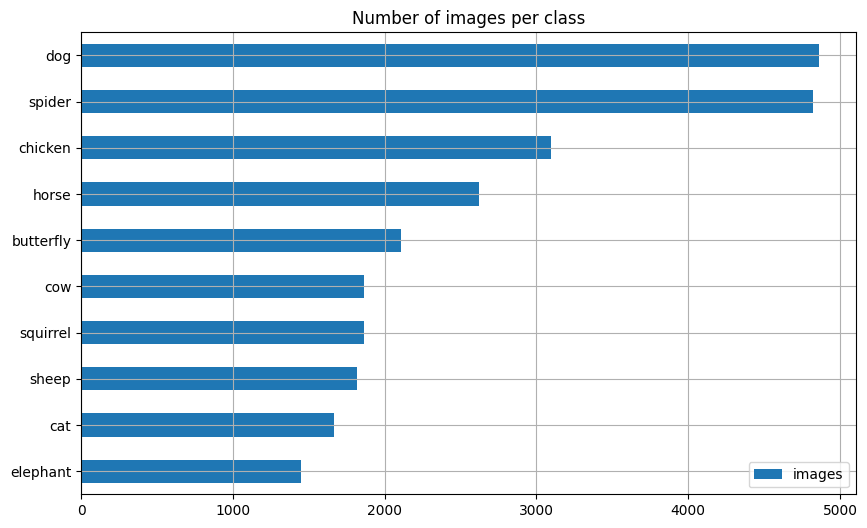

In [6]:
# Plot distribution of images per class
df.sort_values("images").plot(
    kind="barh",
    figsize=(10,6),
    title="Number of images per class"
)
plt.grid(True)
plt.show()

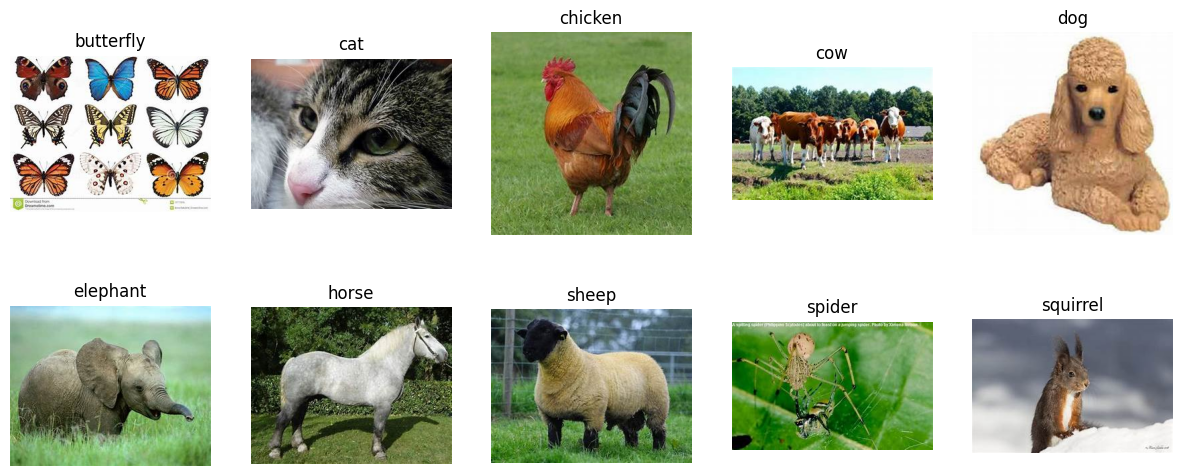

In [17]:
# Sample images

fig, axes = plt.subplots(2,5, figsize=(15,6))

for ax, cls in zip(axes.flatten(), classes):

    img_path = os.path.join(
        data_dir,
        cls,
        random.choice(os.listdir(os.path.join(data_dir, cls)))
    )

    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.show()

In [23]:
# checked for corruption files

corrupted_images = []
total_images = 0

for cls in classes:
    
    class_path = os.path.join(data_dir, cls)
    images = os.listdir(class_path)

    for img_name in tqdm(images, desc=f"Checking {cls}"):

        img_path = os.path.join(class_path, img_name)
        total_images += 1

        try:
            with Image.open(img_path) as img:
                img.verify()

        except Exception:
            corrupted_images.append(img_path)


print("Total images:", total_images)
print("Corrupted images:", len(corrupted_images))

Checking squirrel: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1862/1862 [00:07<00:00, 263.39it/s]

Total images: 26177
Corrupted images: 0


In [16]:
# Check image sizes
sizes = []

for cls in classes:
    folder = os.path.join(data_dir, cls)

    for img_name in os.listdir(folder)[:50]:
        img = Image.open(os.path.join(folder, img_name))
        sizes.append(img.size)

sizes[:10]

[(426, 640),
 (640, 457),
 (426, 640),
 (425, 640),
 (426, 640),
 (640, 454),
 (640, 426),
 (640, 439),
 (640, 416),
 (640, 375)]

In [8]:
# Compute descriptive statistics (min, max, mean, std) for collected image sizes
sizes_df = pd.DataFrame(sizes, columns=["width", "height"])
print("\nImage sizes statistics:")
print(sizes_df.describe())


Image sizes statistics:
            width      height
count  500.000000  500.000000
mean   422.192000  318.164000
std    171.915844  124.744601
min    150.000000  101.000000
25%    300.000000  210.750000
50%    300.000000  300.000000
75%    640.000000  426.000000
max    640.000000  640.000000


## EDA Summary
The dataset structure and class folders were verified during EDA. The class distribution is moderately balanced, with a total of 10 animal classes with approximately 26177 images. All images were checked for corruption and no damaged files were found. Descriptive statistics of image dimensions show significant variation in image sizes across the dataset. Therefore, images will need to be resized to a fixed resolution during preprocessing before model training.Sample images were also visualized to manually verify the correctness of labels and overall image quality.
